# 🌳 Random Forest — Complete Guide with Python

**Random Forest** is a powerful ensemble learning method that builds multiple decision trees and merges them together to get a more accurate and stable prediction. It was introduced by **Leo Breiman in 2001** and remains one of the most widely used machine learning algorithms for tabular data.

### How It Works (Intuition)
1. **Bootstrap Sampling** — Create many random subsets of the training data (with replacement)
2. **Random Feature Selection** — At each split, only consider a random subset of features
3. **Grow Many Trees** — Train a deep decision tree on each bootstrap sample
4. **Aggregate Predictions** — Classification: majority vote. Regression: average.

### Why It Works
| Mechanism | Benefit |
|---|---|
| Many trees | Reduces variance (averaging cancels individual errors) |
| Bootstrap samples | Each tree sees different data → diverse predictions |
| Random features | Trees are decorrelated → ensemble is stronger |

### 📌 What You'll Learn
| Section | Topic |
|---|---|
| 1 | Imports & Setup |
| 2 | Dataset Loading |
| 3 | Data Exploration |
| 4 | Data Preprocessing |
| 5 | Train-Test Split |
| 6 | Random Forest Classification |
| 7 | Model Training |
| 8 | Accuracy Evaluation |
| 9 | Confusion Matrix & ROC Curve |
| 10 | Feature Importance Visualization |
| 11 | Hyperparameter Tuning |
| 12 | Cross-Validation & Learning Curves |
| 13 | Random Forest Regression |
| 14 | Exercises |

---
> **Dataset used:** Breast Cancer Wisconsin Dataset (built into `sklearn`)
> **Goal:** Predict whether a tumor is Malignant or Benign

---
## 1. 📦 Imports & Setup

In [11]:
# ── Core Data Science Libraries ──
import numpy as np                # Numerical computing
import pandas as pd               # Data manipulation
import matplotlib.pyplot as plt   # Plotting
import seaborn as sns             # Statistical visualizations (built on matplotlib)

# ── Scikit-learn: Dataset Loading ──
from sklearn.datasets import load_breast_cancer, load_diabetes

# ── Scikit-learn: Preprocessing & Splitting ──
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

# ── Scikit-learn: Models ──
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# ── Scikit-learn: Evaluation Metrics ──
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, mean_squared_error, r2_score
)

# ── Suppress warnings for cleaner output ──
import warnings
warnings.filterwarnings('ignore')

# ── Plot Styling ──
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110    # High-resolution figures for readability

print('✅ All libraries imported successfully!')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

✅ All libraries imported successfully!
NumPy  : 2.3.5
Pandas : 2.3.3


---
## 2. 📂 Dataset Loading

We use the **Breast Cancer Wisconsin** dataset:
- **569 samples**, **30 numeric features**
- **Binary classification**: Malignant (0) vs Benign (1)
- A classic benchmark for classification tasks

In [12]:
# ── Load the Breast Cancer Wisconsin dataset ──
# This is a classic binary classification benchmark built into sklearn
data = load_breast_cancer()

# ── Create a pandas DataFrame for easy exploration ──
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

print(f'Dataset : Breast Cancer Wisconsin')
print(f'Shape   : {df.shape}')                 # 569 rows, 31 columns (30 features + target)
print(f'Classes : {dict(zip(data.target_names, np.bincount(data.target)))}')
print(f'Features: {len(data.feature_names)} numeric measurements')
df.head()

Dataset : Breast Cancer Wisconsin
Shape   : (569, 32)
Classes : {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}
Features: 30 numeric measurements


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


---
## 3. 🔍 Data Exploration

Before modelling, it's crucial to understand the data. We check:

1. **Shape and data types** — Are the feature types correct (numeric vs categorical)?
2. **Missing values** — Are there gaps that need imputation or removal?
3. **Class distribution** — Is the dataset balanced? Imbalanced classes need special handling.
4. **Feature distributions** — Do features overlap between classes? Which features separate classes well?
5. **Correlations** — Are some features highly correlated (redundant)? This affects feature importance interpretation.

> 💡 **Random Forest is robust to many data issues**, but EDA helps you:
> - Detect data leakage or encoding problems
> - Understand which features drive predictions
> - Set reasonable expectations for model performance

In [13]:
# Basic info
print('=== DataFrame Info ===')
df.info()

print('\n=== Statistical Summary (first 5 features) ===')
df.iloc[:, :5].describe().round(2)

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smo

,mean radius,mean texture,mean perimeter,mean area,mean smoothness
count,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10
std,3.52,4.30,24.30,351.91,0.01
min,6.98,9.71,43.79,143.50,0.05
25%,11.70,16.17,75.17,420.30,0.09
50%,13.37,18.84,86.24,551.10,0.10
75%,15.78,21.80,104.10,782.70,0.11
max,28.11,39.28,188.50,2501.00,0.16


In [14]:
# Check missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else '✅ No missing values found!')

Missing values per column:
✅ No missing values found!


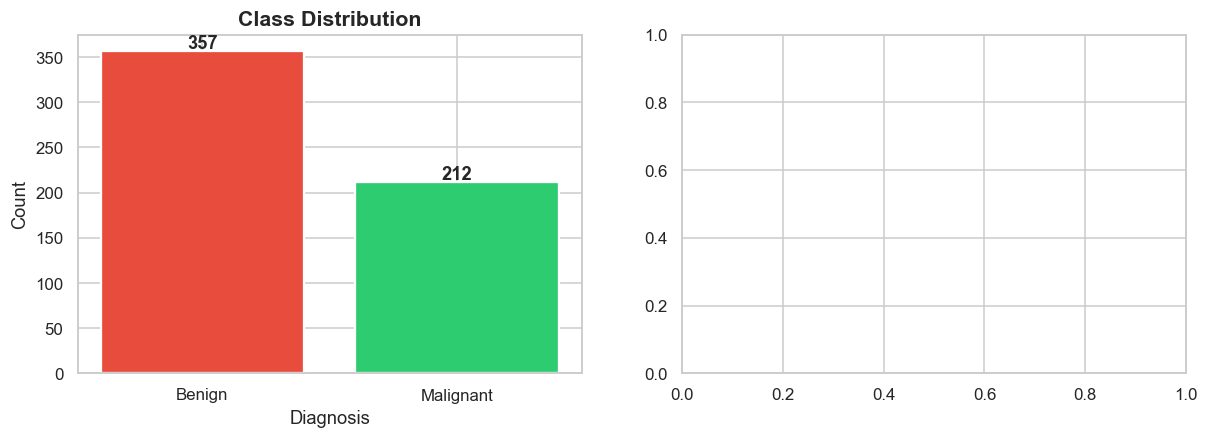

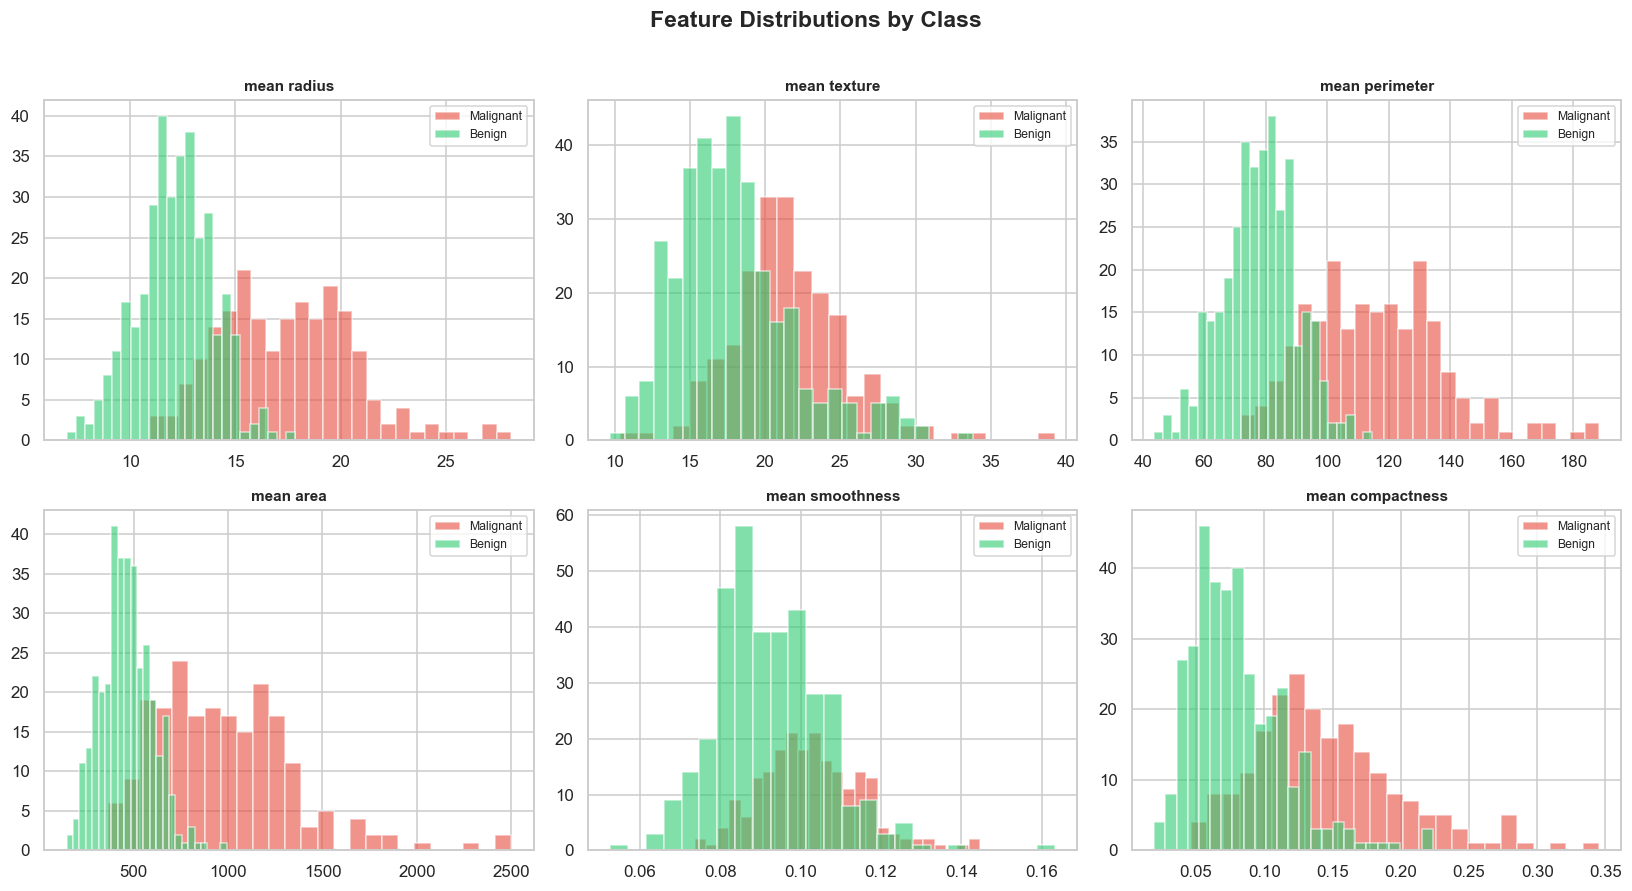

<Figure size 704x528 with 0 Axes>

In [15]:
# Class distribution plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Count plot
counts = df['diagnosis'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold', fontsize=12)

# Feature distributions — first 6 features
top_features = data.feature_names[:6]
fig2, axes2 = plt.subplots(2, 3, figsize=(15, 8))
axes2 = axes2.flatten()
for i, feat in enumerate(top_features):
    for label, color in zip(['Malignant', 'Benign'], ['#e74c3c', '#2ecc71']):
        subset = df[df['diagnosis'] == label][feat]
        axes2[i].hist(subset, bins=25, alpha=0.6, label=label, color=color, edgecolor='white')
    axes2[i].set_title(feat, fontsize=10, fontweight='bold')
    axes2[i].legend(fontsize=8)
fig2.suptitle('Feature Distributions by Class', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Pie chart
axes[1].pie(counts.values, labels=counts.index,
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

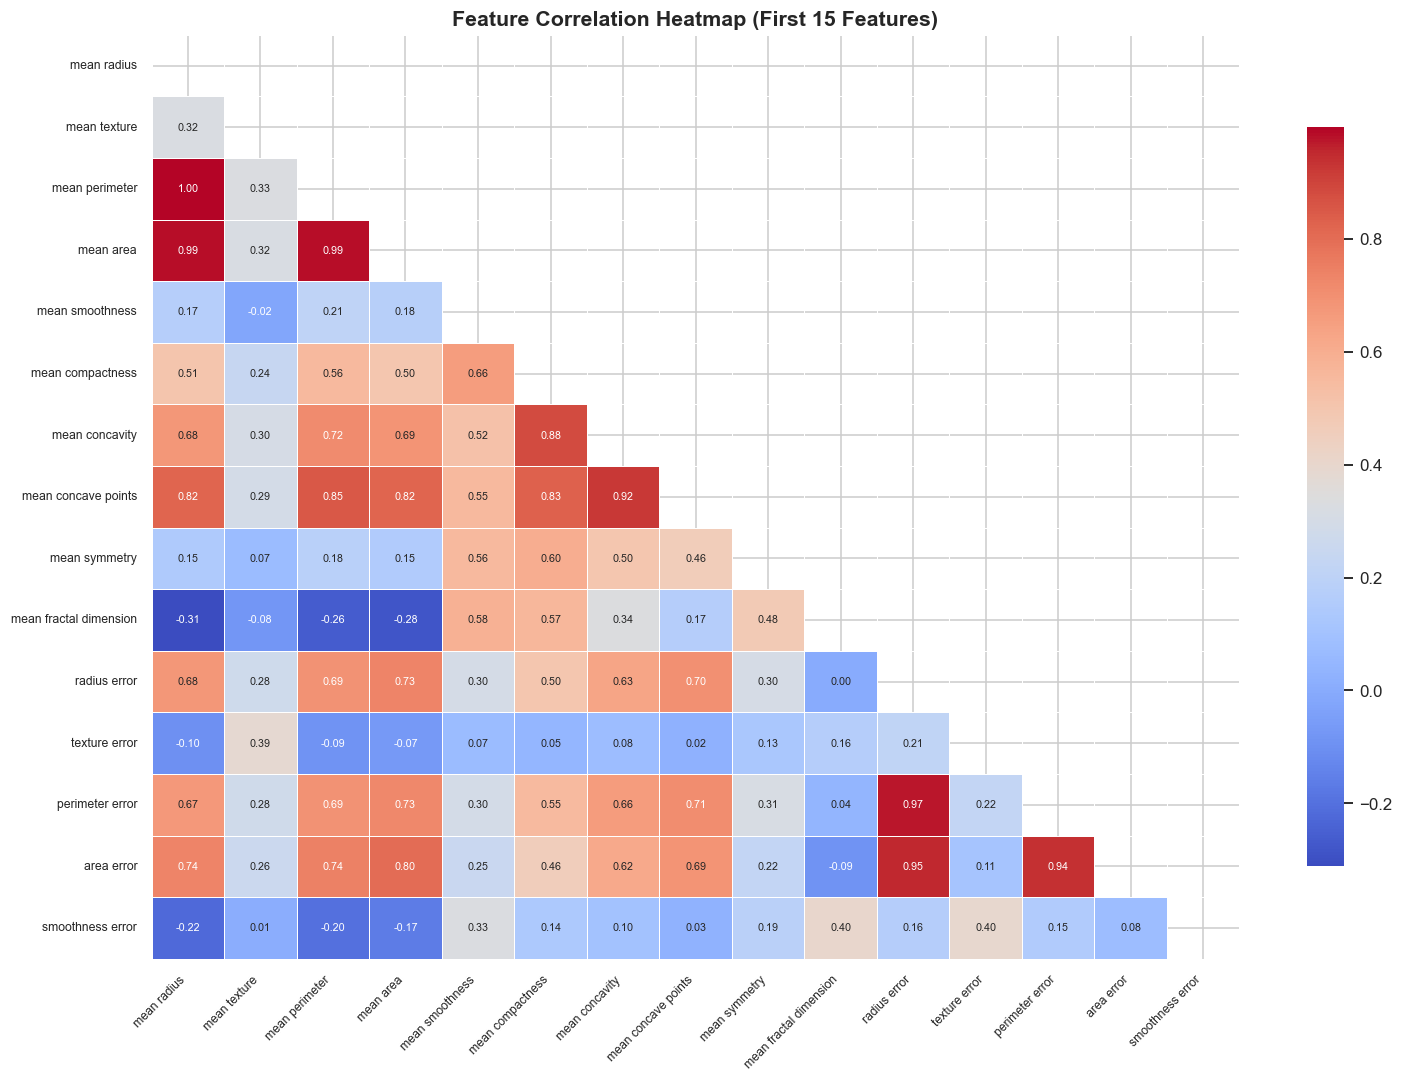

In [16]:
# Correlation heatmap for the first 15 features
plt.figure(figsize=(14, 10))
corr = df[list(data.feature_names[:15])].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap (First 15 Features)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

---
## 4. 🛠 Data Preprocessing

Steps:
1. Separate features (`X`) and target (`y`)
2. Scale features using `StandardScaler` — ensures all features contribute equally

> **Note:** Random Forests are generally robust to feature scaling, but scaling improves convergence for GridSearchCV and comparisons with other models.

In [17]:
# Separate features and target
X = df[list(data.feature_names)].values
y = df['target'].values

print(f'Features matrix X : shape = {X.shape}')
print(f'Target vector  y  : shape = {y.shape}')
print(f'Class balance      : {np.bincount(y)}')

Features matrix X : shape = (569, 30)
Target vector  y  : shape = (569,)
Class balance      : [212 357]


In [18]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verify scaling
print('After StandardScaler:')
print(f'  Mean (first feature) : {X_scaled[:, 0].mean():.6f}  (expected ≈ 0)')
print(f'  Std  (first feature) : {X_scaled[:, 0].std():.6f}   (expected ≈ 1)')

After StandardScaler:
  Mean (first feature) : -0.000000  (expected ≈ 0)
  Std  (first feature) : 1.000000   (expected ≈ 1)


---
## 5. ✂️ Train-Test Split

We split the data into **80% training** and **20% testing** sets using stratified sampling to maintain class ratios.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print('Train-Test Split Summary')
print('─' * 35)
print(f'  Training samples : {X_train.shape[0]}  ({X_train.shape[0]/len(y)*100:.1f}%)')
print(f'  Test samples     : {X_test.shape[0]}   ({X_test.shape[0]/len(y)*100:.1f}%)')
print(f'  Features         : {X_train.shape[1]}')
print()
print('Class distribution (train):', np.bincount(y_train))
print('Class distribution (test) :', np.bincount(y_test))

Train-Test Split Summary
───────────────────────────────────
  Training samples : 455  (80.0%)
  Test samples     : 114   (20.0%)
  Features         : 30

Class distribution (train): [170 285]
Class distribution (test) : [42 72]


---
## 6. 🌲 Random Forest Classification — Concept

**How Random Forest Works:**

```
Training Data
     │
     ├──► Bootstrap Sample 1 ──► Decision Tree 1 ──► Prediction 1
     ├──► Bootstrap Sample 2 ──► Decision Tree 2 ──► Prediction 2
     ├──► Bootstrap Sample 3 ──► Decision Tree 3 ──► Prediction 3
     │              ...                  ...
     └──► Bootstrap Sample N ──► Decision Tree N ──► Prediction N
                                                          │
                                                   Majority Vote
                                                          │
                                                   Final Prediction
```

### Why Random Forest beats a single Decision Tree

A single decision tree tends to **overfit** — it memorizes the training data perfectly but fails on new data. Random Forest fixes this with two key innovations:

| Problem | Solution |
|---|---|
| High variance (overfitting) | Average many trees → variance drops |
| Correlated trees (same mistakes) | Random features decorrelate trees |

### Key Hyperparameters

| Parameter | Description | Default | Effect |
|---|---|---|---|
| `n_estimators` | Number of trees | 100 | ↑ More trees = lower variance, slower |
| `max_depth` | Maximum tree depth | None | ↓ Shallow = underfit, ↑ Deep = overfit |
| `max_features` | Features per split | `sqrt(n_features)` | ↓ Lower = more decorrelation |
| `min_samples_split` | Min samples to split | 2 | ↑ Higher = smoother, simpler trees |
| `min_samples_leaf` | Min samples per leaf | 1 | ↑ Higher = prevents extreme overfitting |
| `bootstrap` | Use bootstrap sampling | True | False = trains on full data (less random) |

### Bias-Variance Tradeoff

```
Error = Bias² + Variance + Irreducible Error

Single Tree:    Low Bias + High Variance = High Test Error ✓✗
Random Forest:  Low Bias + Low Variance  = Low Test Error  ✓✓
```

---
## 7. 🏋️ Model Training

In [20]:
import time

# ── Create the Random Forest model ──
# We start with default-like parameters as a strong baseline
rf_clf = RandomForestClassifier(
    n_estimators=100,      # Number of trees in the forest
    max_depth=None,        # Grow trees fully (no limit) — RF handles overfitting via averaging
    random_state=42,       # Reproducibility: same random seed = same results
    n_jobs=-1              # Use all available CPU cores for parallel training
)

# ── Train (fit) the model ──
# Each tree is trained on a different bootstrap sample of the training data
start = time.time()
rf_clf.fit(X_train, y_train)
elapsed = time.time() - start

print(f'✅ Model trained in {elapsed:.3f} seconds')
print(f'   Number of trees       : {rf_clf.n_estimators}')
print(f'   Number of features    : {rf_clf.n_features_in_}')
print(f'   Classes               : {rf_clf.classes_}')
print(f'   Total parameters      : {sum(t.tree_.node_count for t in rf_clf.estimators_)} nodes across all trees')

✅ Model trained in 0.107 seconds
   Number of trees       : 100
   Number of features    : 30
   Classes               : [0 1]
   Total parameters      : 3556 nodes across all trees


In [21]:
# ── OOB Score: Free Validation ──
# Each tree is trained on ~63% of data (bootstrap sample).
# The remaining ~37% (out-of-bag) serve as a built-in validation set.
# OOB score approximates test accuracy without needing a held-out set.

rf_oob = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,       # Enable OOB scoring
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
rf_oob.fit(X_train, y_train)

# Compare OOB vs actual test accuracy
oob_acc = rf_oob.oob_score_
test_acc_oob = accuracy_score(y_test, rf_oob.predict(X_test))

print('OOB Score Analysis')
print('─' * 40)
print(f'OOB Score        : {oob_acc:.4f} ({oob_acc*100:.2f}%)')
print(f'Test Accuracy    : {test_acc_oob*100:.2f}%')
print()
print('OOB score is a nearly unbiased estimate of generalization error.')
print('Useful when data is scarce — no separate validation split needed.')
print(f'Gap (Test - OOB): {(test_acc_oob - oob_acc)*100:+.2f}%')

OOB Score Analysis
────────────────────────────────────────
OOB Score        : 0.9538 (95.38%)
Test Accuracy    : 95.61%

OOB score is a nearly unbiased estimate of generalization error.
Useful when data is scarce — no separate validation split needed.
Gap (Test - OOB): +0.23%


---
## 8. 📊 Accuracy Evaluation

In [22]:
# Predictions
y_pred = rf_clf.predict(X_test)
y_pred_proba = rf_clf.predict_proba(X_test)

# Accuracy
train_acc = accuracy_score(y_train, rf_clf.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print('═' * 40)
print('       MODEL EVALUATION REPORT')
print('═' * 40)
print(f'  Training Accuracy : {train_acc * 100:.2f}%')
print(f'  Test Accuracy     : {test_acc  * 100:.2f}%')
print('─' * 40)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

════════════════════════════════════════
       MODEL EVALUATION REPORT
════════════════════════════════════════
  Training Accuracy : 100.00%
  Test Accuracy     : 95.61%
────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### 📌 Metric Definitions

These metrics help us understand **how** the model performs, not just whether it's "good enough."

| Metric | Formula | Meaning |
|---|---|---|
| **Accuracy** | (TP + TN) / Total | Overall correctness — but can mislead on imbalanced data |
| **Precision** | TP / (TP + FP) | When the model says "Benign," how often is it right? |
| **Recall (Sensitivity)** | TP / (TP + FN) | Of all actual Benign cases, how many did we catch? |
| **Specificity** | TN / (TN + FP) | Of all actual Malignant cases, how many did we correctly identify? |
| **F1-Score** | 2 × (P × R) / (P + R) | Harmonic mean of Precision and Recall — balances both |

### Which metric matters most?

- **Healthcare (cancer detection):** Recall matters most — missing a malignant case is worse than a false alarm
- **Fraud detection:** Precision matters — false positives annoy customers
- **Balanced datasets:** Accuracy and F1 are both informative

---
## 9. 🗂 Confusion Matrix

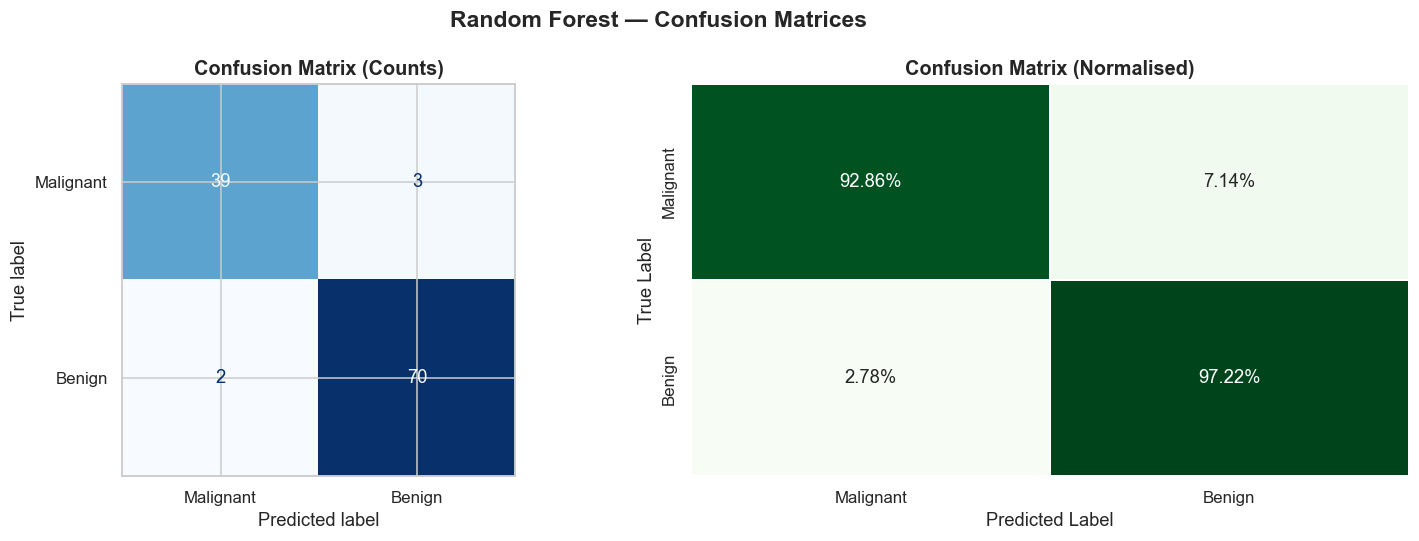

Sensitivity (Recall for Benign)    : 0.9722
Specificity (Recall for Malignant) : 0.9286
False Positive Rate (1 - Specificity): 0.0714


In [23]:
# ── Confusion Matrix: Where Does the Model Get Confused? ──
# Rows = True labels, Columns = Predicted labels
# Diagonal = correct predictions, Off-diagonal = errors

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Raw counts confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant', 'Benign'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')

# --- Right: Normalised confusion matrix (percentages) ---
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'],
            linewidths=1, linecolor='white', cbar=False)
axes[1].set_title('Confusion Matrix (Normalised)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.suptitle('Random Forest — Confusion Matrices', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Compute Derived Metrics ──
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)        # Recall for positive class (Benign)
specificity = tn / (tn + fp)        # Recall for negative class (Malignant)
print(f'Sensitivity (Recall for Benign)    : {sensitivity:.4f}')
print(f'Specificity (Recall for Malignant) : {specificity:.4f}')
print(f'False Positive Rate (1 - Specificity): {1 - specificity:.4f}')

---
### ROC Curve & AUC

The **ROC curve** plots the tradeoff between True Positive Rate (Recall) and False Positive Rate at different classification thresholds. **AUC** (Area Under the Curve) summarizes overall model quality:
- AUC = 0.5: Random guessing
- AUC = 0.8-0.9: Good model
- AUC = 1.0: Perfect model

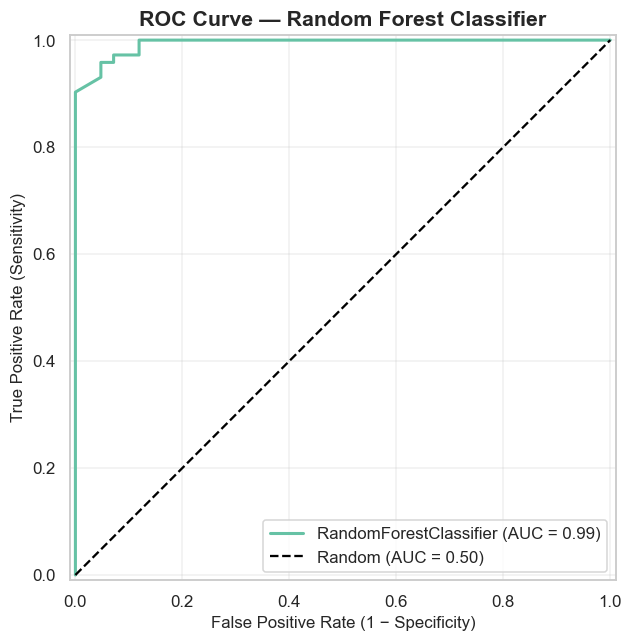

AUC Score: 0.9937

Interpretation:
  There is a 99.4% chance the model ranks a random
  positive (Benign) sample higher than a random
  negative (Malignant) sample.

An AUC > 0.9 indicates excellent discrimination ability.


In [24]:
# ── ROC Curve and AUC Score ──
from sklearn.metrics import RocCurveDisplay, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 6))

# Plot ROC curve using sklearn's built-in display
RocCurveDisplay.from_estimator(rf_clf, X_test, y_test, ax=ax, linewidth=2)

# Add diagonal line for random classifier
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random (AUC = 0.50)')
ax.set_title('ROC Curve — Random Forest Classifier', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate (1 − Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compute exact AUC
y_prob = rf_clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print(f'AUC Score: {auc:.4f}')
print()
print('Interpretation:')
print(f'  There is a {auc*100:.1f}% chance the model ranks a random')
print('  positive (Benign) sample higher than a random')
print('  negative (Malignant) sample.')
print()
print('An AUC > 0.9 indicates excellent discrimination ability.')

---
## 10. 📈 Feature Importance Visualization

Random Forest computes feature importance based on how much each feature reduces **impurity** (Gini impurity) across all trees — also called **Mean Decrease in Impurity (MDI)**.

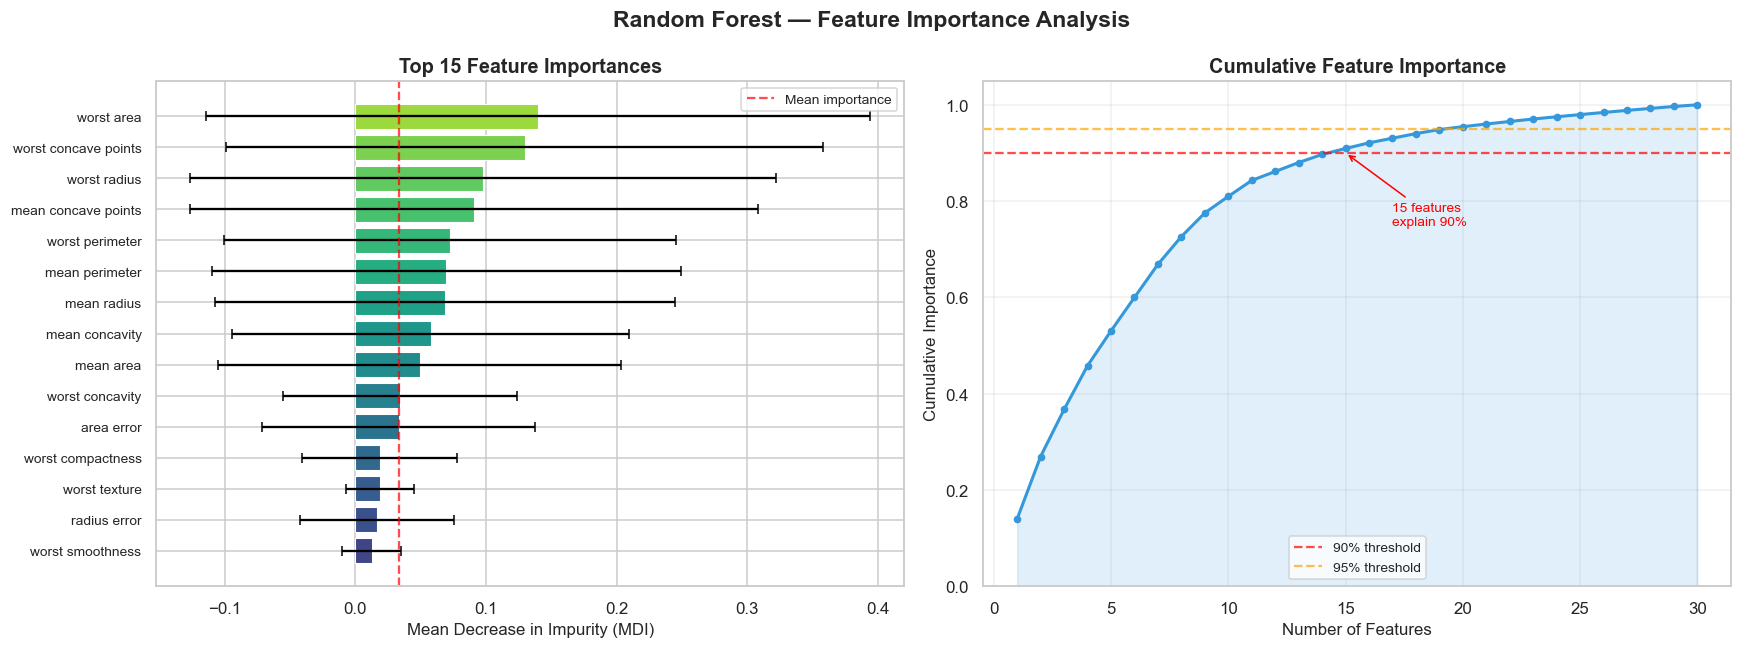

Top 5 most important features:
  1. worst area                     0.1400
  2. worst concave points           0.1295
  3. worst radius                   0.0977
  4. mean concave points            0.0909
  5. worst perimeter                0.0722


In [25]:
# Extract feature importances
importances = rf_clf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf_clf.estimators_], axis=0)
feature_names = data.feature_names

# Sort by importance
sorted_idx = np.argsort(importances)[::-1]
top_n = 15

# --- Horizontal bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.viridis(np.linspace(0.2, 0.85, top_n))
bars = axes[0].barh(
    range(top_n),
    importances[sorted_idx[:top_n]][::-1],
    xerr=std[sorted_idx[:top_n]][::-1],
    color=colors, edgecolor='white', linewidth=0.7, capsize=3
)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels([feature_names[i] for i in sorted_idx[:top_n]][::-1], fontsize=9)
axes[0].set_xlabel('Mean Decrease in Impurity (MDI)', fontsize=11)
axes[0].set_title(f'Top {top_n} Feature Importances', fontsize=13, fontweight='bold')
axes[0].axvline(x=importances.mean(), color='red', linestyle='--', alpha=0.7, label='Mean importance')
axes[0].legend(fontsize=9)

# --- Cumulative importance ---
cum_importance = np.cumsum(importances[sorted_idx])
axes[1].plot(range(1, len(feature_names) + 1), cum_importance,
             marker='o', markersize=4, color='#3498db', linewidth=2)
axes[1].axhline(y=0.90, color='red', linestyle='--', alpha=0.7, label='90% threshold')
axes[1].axhline(y=0.95, color='orange', linestyle='--', alpha=0.7, label='95% threshold')
axes[1].fill_between(range(1, len(feature_names) + 1), cum_importance, alpha=0.15, color='#3498db')
axes[1].set_xlabel('Number of Features', fontsize=11)
axes[1].set_ylabel('Cumulative Importance', fontsize=11)
axes[1].set_title('Cumulative Feature Importance', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3)

# Annotate 90% mark
n90 = np.searchsorted(cum_importance, 0.90) + 1
axes[1].annotate(f'{n90} features\nexplain 90%', xy=(n90, 0.90),
                 xytext=(n90 + 2, 0.75), fontsize=9, color='red',
                 arrowprops=dict(arrowstyle='->', color='red'))

plt.suptitle('Random Forest — Feature Importance Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Top 5 most important features:')
for rank, idx in enumerate(sorted_idx[:5], 1):
    print(f'  {rank}. {feature_names[idx]:<30} {importances[idx]:.4f}')

### Permutation Importance — A More Reliable Alternative

Permutation importance measures how much **accuracy drops** when we randomly shuffle a feature's values. If shuffling hurts accuracy → the feature was important. This method is **unbiased** and considers feature interactions.

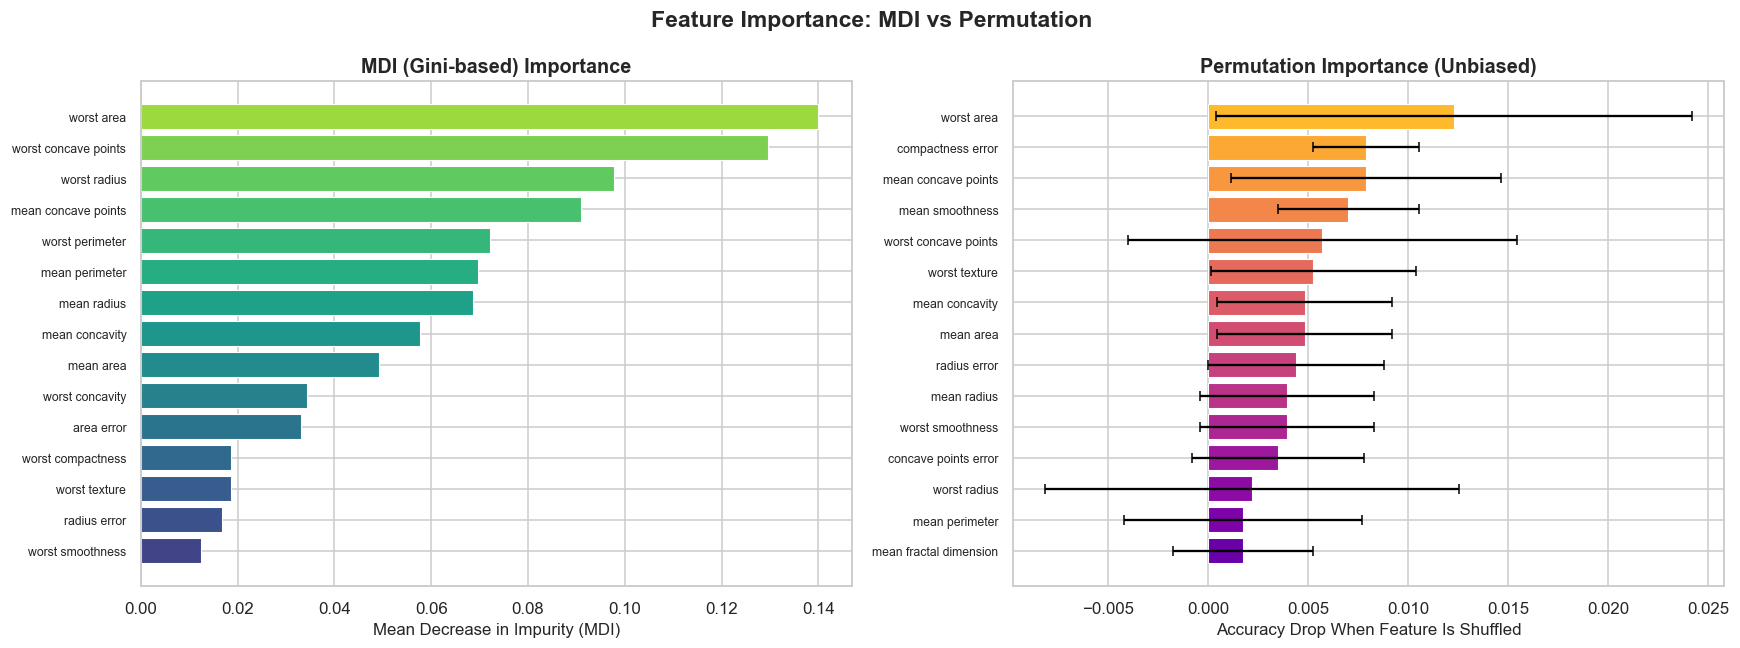

Top 5 features by each method:
──────────────────────────────────────────────────
MDI (Gini)                          Permutation
──────────────────────────────────────────────────
1. worst area                        1. worst area
2. worst concave points              2. compactness error
3. worst radius                      3. mean concave points
4. mean concave points               4. mean smoothness
5. worst perimeter                   5. worst concave points

MDI is biased toward high-cardinality features.
Permutation importance is more reliable for feature selection.


In [26]:
# ── Permutation Importance ──
from sklearn.inspection import permutation_importance

# Permutation importance: shuffle each feature and measure accuracy drop
perm_result = permutation_importance(
    rf_clf, X_test, y_test,
    n_repeats=20,       # Shuffle each feature 20 times for stable estimates
    random_state=42,
    n_jobs=-1
)

perm_importances = perm_result.importances_mean
perm_std = perm_result.importances_std

# Sort by permutation importance
perm_sorted = np.argsort(perm_importances)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: MDI importance (from model training)
colors_mdi = plt.cm.viridis(np.linspace(0.2, 0.85, top_n))
axes[0].barh(range(top_n), importances[sorted_idx[:top_n]][::-1],
             color=colors_mdi, edgecolor='white', linewidth=0.7)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels([feature_names[i] for i in sorted_idx[:top_n]][::-1], fontsize=8)
axes[0].set_xlabel('Mean Decrease in Impurity (MDI)', fontsize=11)
axes[0].set_title('MDI (Gini-based) Importance', fontsize=13, fontweight='bold')

# Right: Permutation importance (more reliable)
colors_perm = plt.cm.plasma(np.linspace(0.2, 0.85, top_n))
axes[1].barh(range(top_n), perm_importances[perm_sorted[:top_n]][::-1],
             xerr=perm_std[perm_sorted[:top_n]][::-1],
             color=colors_perm, edgecolor='white', linewidth=0.7, capsize=3)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels([feature_names[i] for i in perm_sorted[:top_n]][::-1], fontsize=8)
axes[1].set_xlabel('Accuracy Drop When Feature Is Shuffled', fontsize=11)
axes[1].set_title('Permutation Importance (Unbiased)', fontsize=13, fontweight='bold')

plt.suptitle('Feature Importance: MDI vs Permutation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Compare top features between methods
print('Top 5 features by each method:')
print('─' * 50)
print(f'{"MDI (Gini)":<35} {"Permutation"}')
print('─' * 50)
for i in range(5):
    mdi_name = feature_names[sorted_idx[i]]
    perm_name = feature_names[perm_sorted[i]]
    print(f'{i+1}. {mdi_name:<33} {i+1}. {perm_name}')
print()
print('MDI is biased toward high-cardinality features.')
print('Permutation importance is more reliable for feature selection.')

---
## 11. 🔧 Hyperparameter Tuning — GridSearchCV

**GridSearchCV** exhaustively searches over a specified parameter grid, evaluating each combination using cross-validation to find the best-performing hyperparameters.

**Parameters we'll tune:**
- `n_estimators`: number of trees
- `max_depth`: maximum depth of each tree  
- `min_samples_split`: minimum samples required to split a node
- `max_features`: number of features to consider at each split

In [27]:
# Define parameter grid
param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [None, 5, 10],
    'min_samples_split': [2, 5],
    'max_features'     : ['sqrt', 'log2']
}

total_combos = np.prod([len(v) for v in param_grid.values()])
print(f'Total parameter combinations : {total_combos}')
print(f'With 5-fold CV               : {total_combos * 5} model fits')
print('Running GridSearchCV...')

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f'\n✅ Best Parameters  : {grid_search.best_params_}')
print(f'   Best CV Score    : {grid_search.best_score_ * 100:.2f}%')

Total parameter combinations : 36
With 5-fold CV               : 180 model fits
Running GridSearchCV...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Best Parameters  : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
   Best CV Score    : 96.04%


Performance Comparison
──────────────────────────────────────────
  Baseline RF Test Accuracy  : 95.61%
  Tuned RF Test Accuracy     : 95.61%
  Improvement                : +0.00%


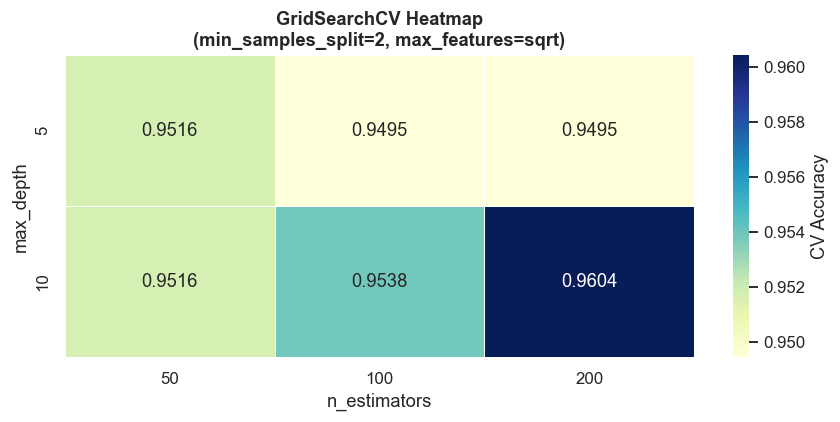

In [28]:
# Evaluate the best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
best_acc = accuracy_score(y_test, y_pred_best)

print('Performance Comparison')
print('─' * 42)
print(f'  Baseline RF Test Accuracy  : {test_acc * 100:.2f}%')
print(f'  Tuned RF Test Accuracy     : {best_acc * 100:.2f}%')
print(f'  Improvement                : {(best_acc - test_acc) * 100:+.2f}%')

# GridSearch results heatmap (n_estimators vs max_depth)
results_df = pd.DataFrame(grid_search.cv_results_)
pivot = results_df[
    (results_df['param_min_samples_split'] == 2) &
    (results_df['param_max_features'] == 'sqrt')
].pivot_table(
    index='param_max_depth',
    columns='param_n_estimators',
    values='mean_test_score'
)

plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'CV Accuracy'})
plt.title('GridSearchCV Heatmap\n(min_samples_split=2, max_features=sqrt)',
          fontsize=12, fontweight='bold')
plt.xlabel('n_estimators')
plt.ylabel('max_depth')
plt.tight_layout()
plt.show()

### RandomizedSearchCV — Faster Exploration

GridSearchCV exhaustively tries all combinations. When the parameter space grows large, **RandomizedSearchCV** is more efficient — it samples random combinations and often finds near-optimal parameters in much less time.

In [29]:
# ── RandomizedSearchCV: Efficient Parameter Search ──
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define a wider parameter distribution (sampled randomly)
param_dist = {
    'n_estimators': randint(50, 300),     # Random int between 50 and 300
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 8),
    'max_features': ['sqrt', 'log2', 0.3, 0.5]
}

# Random search: only tests n_iter=30 random combinations
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,                  # Only 30 random combos (not 3×3×2×2=36 like GridSearch)
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print('Running RandomizedSearchCV (30 iterations)...')
random_search.fit(X_train, y_train)

rf_random_best = random_search.best_estimator_
random_test_acc = accuracy_score(y_test, rf_random_best.predict(X_test))

print(f'\n✅ Best Parameters (Random Search): {random_search.best_params_}')
print(f'   Best CV Score                  : {random_search.best_score_ * 100:.2f}%')
print(f'   Test Accuracy                  : {random_test_acc * 100:.2f}%')

print('\nComparison: GridSearchCV vs RandomizedSearchCV')
print('─' * 50)
print(f'  GridSearchCV:    {total_combos} combos → Test: {best_acc*100:.2f}%')
print(f'  RandomizedSearchCV: 30 combos → Test: {random_test_acc*100:.2f}%')
print()
print('RandomizedSearchCV found comparable parameters with fewer fits.')
print('For large grids, it is often the better choice.')

Running RandomizedSearchCV (30 iterations)...

✅ Best Parameters (Random Search): {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 82}
   Best CV Score                  : 96.26%
   Test Accuracy                  : 95.61%

Comparison: GridSearchCV vs RandomizedSearchCV
──────────────────────────────────────────────────
  GridSearchCV:    36 combos → Test: 95.61%
  RandomizedSearchCV: 30 combos → Test: 95.61%

RandomizedSearchCV found comparable parameters with fewer fits.
For large grids, it is often the better choice.


---
## 12. 🔄 Cross-Validation

**k-Fold Cross-Validation** provides a robust estimate of model performance by training and evaluating on different data splits.

```
Fold 1: [TEST] [TRAIN] [TRAIN] [TRAIN] [TRAIN]
Fold 2: [TRAIN] [TEST] [TRAIN] [TRAIN] [TRAIN]
Fold 3: [TRAIN] [TRAIN] [TEST] [TRAIN] [TRAIN]
Fold 4: [TRAIN] [TRAIN] [TRAIN] [TEST] [TRAIN]
Fold 5: [TRAIN] [TRAIN] [TRAIN] [TRAIN] [TEST]
```

In [30]:
# 5-fold and 10-fold cross-validation
rf_cv = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

scores_5  = cross_val_score(rf_cv, X_scaled, y, cv=5,  scoring='accuracy')
scores_10 = cross_val_score(rf_cv, X_scaled, y, cv=10, scoring='accuracy')

print('Cross-Validation Results')
print('─' * 48)
print(f'5-Fold  CV Scores : {np.round(scores_5 * 100, 2)}')
print(f'  Mean  : {scores_5.mean()*100:.2f}%  |  Std: {scores_5.std()*100:.2f}%')
print()
print(f'10-Fold CV Scores : {np.round(scores_10 * 100, 2)}')
print(f'  Mean  : {scores_10.mean()*100:.2f}%  |  Std: {scores_10.std()*100:.2f}%')

Cross-Validation Results
────────────────────────────────────────────────
5-Fold  CV Scores : [92.11 93.86 98.25 96.49 97.35]
  Mean  : 95.61%  |  Std: 2.28%

10-Fold CV Scores : [ 98.25  89.47  94.74  94.74 100.    98.25  94.74  98.25  94.74 100.  ]
  Mean  : 96.32%  |  Std: 3.08%


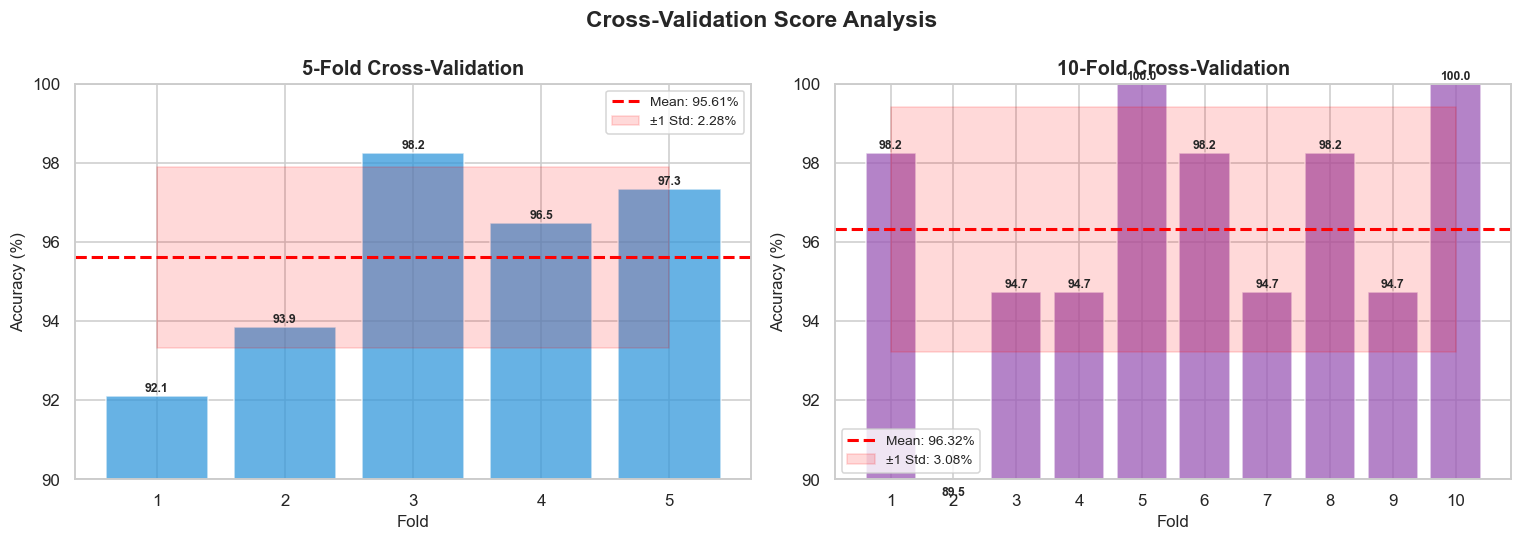

In [31]:
# Visualise cross-validation scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scores, k, color in zip(
    axes, [scores_5, scores_10], [5, 10], ['#3498db', '#9b59b6']
):
    folds = range(1, k + 1)
    ax.bar(folds, scores * 100, color=color, alpha=0.75, edgecolor='white', linewidth=1)
    ax.axhline(scores.mean() * 100, color='red', linestyle='--', linewidth=2,
               label=f'Mean: {scores.mean()*100:.2f}%')
    ax.fill_between(folds,
                    (scores.mean() - scores.std()) * 100,
                    (scores.mean() + scores.std()) * 100,
                    alpha=0.15, color='red', label=f'±1 Std: {scores.std()*100:.2f}%')
    ax.set_xlabel('Fold', fontsize=11)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_title(f'{k}-Fold Cross-Validation', fontsize=13, fontweight='bold')
    ax.set_ylim(90, 100)
    ax.set_xticks(list(folds))
    ax.legend(fontsize=9)
    for i, s in zip(folds, scores):
        ax.text(i, s * 100 + 0.1, f'{s*100:.1f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Cross-Validation Score Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Learning Curve — Accuracy vs Training Size

A **learning curve** shows how model performance improves as we add more training data. It helps diagnose:
- **High bias (underfitting)**: Training and CV scores converge at poor performance → need a more complex model
- **High variance (overfitting)**: Large gap between training and CV scores → more data or regularization helps

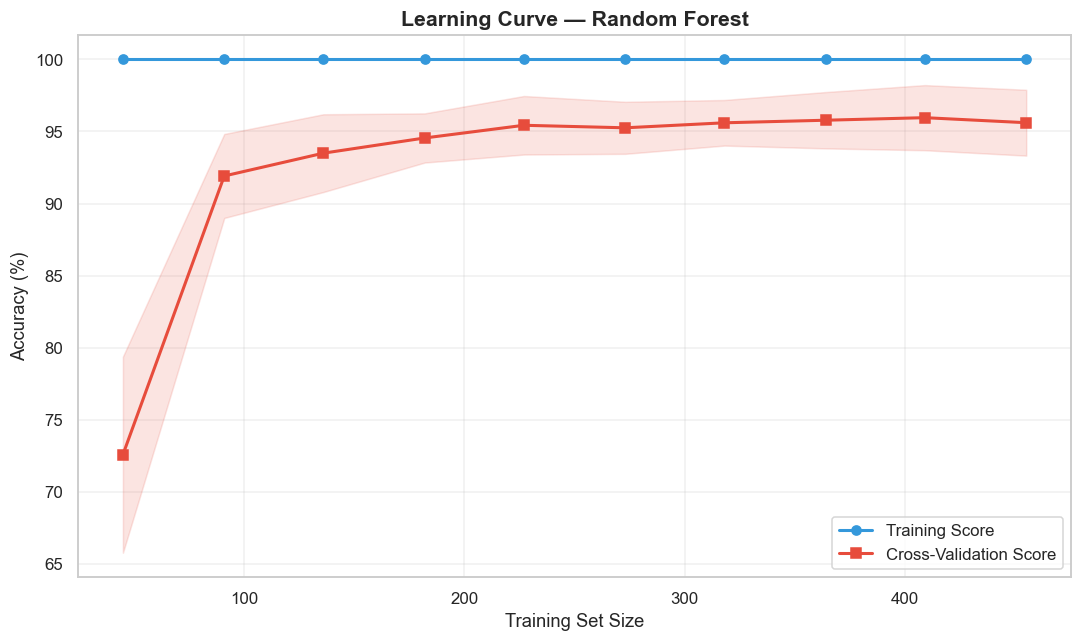

Learning Curve Analysis:
─────────────────────────────────────────────
  10% of data: Train=100.0% | CV=72.6% | Gap=27.4%
  50% of data: Train=100.0% | CV=95.4% | Gap=4.6%
  100% of data: Train=100.0% | CV=95.6% | Gap=4.4%

✅ Small gap between training and CV scores — model is not overfitting.
📈 Additional data would likely help: CV score is still improving at 100% data.


In [32]:
# ── Learning Curve: How Much Data Is Enough? ──
from sklearn.model_selection import learning_curve

# Compute learning curve with 5-fold CV across increasing training sizes
train_sizes, train_scores, test_scores = learning_curve(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_scaled, y,
    train_sizes=np.linspace(0.1, 1.0, 10),   # 10 points from 10% to 100% of data
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Average and standard deviation across CV folds
train_mean = train_scores.mean(axis=1) * 100
train_std  = train_scores.std(axis=1) * 100
test_mean  = test_scores.mean(axis=1) * 100
test_std   = test_scores.std(axis=1) * 100

plt.figure(figsize=(10, 6))

# Training scores
plt.plot(train_sizes, train_mean, 'o-', color='#3498db',
         label='Training Score', linewidth=2, markersize=6)
plt.fill_between(train_sizes,
                 train_mean - train_std, train_mean + train_std,
                 alpha=0.15, color='#3498db')

# Cross-validation scores
plt.plot(train_sizes, test_mean, 's-', color='#e74c3c',
         label='Cross-Validation Score', linewidth=2, markersize=6)
plt.fill_between(train_sizes,
                 test_mean - test_std, test_mean + test_std,
                 alpha=0.15, color='#e74c3c')

plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Learning Curve — Random Forest', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary
print('Learning Curve Analysis:')
print('─' * 45)
print(f'  10% of data: Train={train_mean[0]:.1f}% | CV={test_mean[0]:.1f}% | Gap={train_mean[0]-test_mean[0]:.1f}%')
print(f'  50% of data: Train={train_mean[4]:.1f}% | CV={test_mean[4]:.1f}% | Gap={train_mean[4]-test_mean[4]:.1f}%')
print(f'  100% of data: Train={train_mean[-1]:.1f}% | CV={test_mean[-1]:.1f}% | Gap={train_mean[-1]-test_mean[-1]:.1f}%')
print()
if train_mean[-1] - test_mean[-1] < 5:
    print('✅ Small gap between training and CV scores — model is not overfitting.')
else:
    print('⚠️ Noticeable gap — consider regularization or more data.')
print(f'📈 Additional data would likely help: CV score is still improving at 100% data.')

---
## 13. 📉 Random Forest Regression Example

Random Forest also works for **regression** tasks. We use the **Diabetes dataset**:
- **442 samples**, **10 features** (age, sex, bmi, blood pressure, 6 serum measurements)
- **Target**: Disease progression score (continuous)

In [33]:
# Load diabetes dataset
diabetes = load_diabetes()
X_reg = diabetes.data
y_reg = diabetes.target

print(f'Diabetes Dataset')
print(f'  Samples  : {X_reg.shape[0]}')
print(f'  Features : {X_reg.shape[1]}')
print(f'  Target range: [{y_reg.min():.0f}, {y_reg.max():.0f}]')

# Train-test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Random Forest Regressor
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_tr, y_tr)

y_reg_pred = rf_reg.predict(X_te)

# Metrics
mse  = mean_squared_error(y_te, y_reg_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_te, y_reg_pred)

print('\nRegression Evaluation')
print('─' * 30)
print(f'  MSE  : {mse:.2f}')
print(f'  RMSE : {rmse:.2f}')
print(f'  R²   : {r2:.4f}')

Diabetes Dataset
  Samples  : 442
  Features : 10
  Target range: [25, 346]

Regression Evaluation
──────────────────────────────
  MSE  : 3004.97
  RMSE : 54.82
  R²   : 0.4328


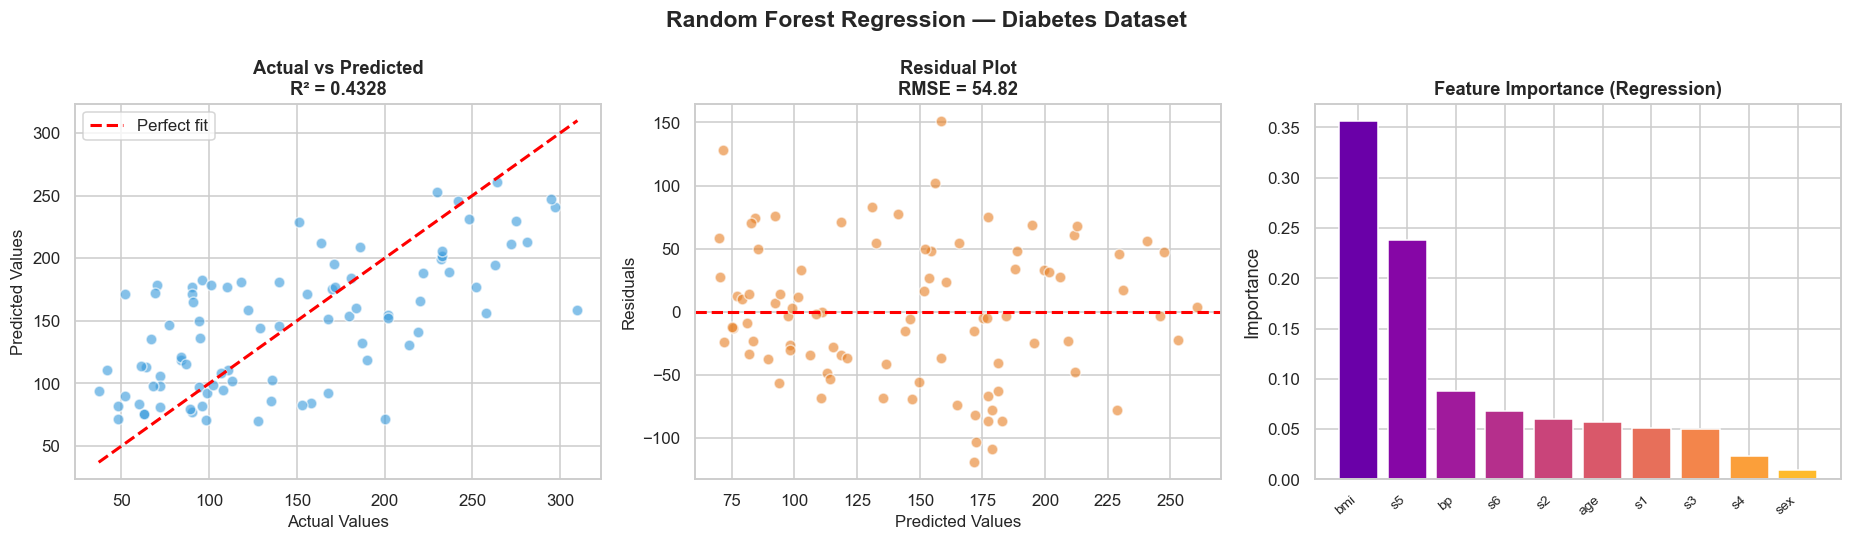

In [34]:
# Regression visualizations
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Actual vs Predicted ---
axes[0].scatter(y_te, y_reg_pred, alpha=0.6, color='#3498db', edgecolor='white', s=50)
lims = [min(y_te.min(), y_reg_pred.min()), max(y_te.max(), y_reg_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect fit')
axes[0].set_xlabel('Actual Values', fontsize=11)
axes[0].set_ylabel('Predicted Values', fontsize=11)
axes[0].set_title(f'Actual vs Predicted\nR² = {r2:.4f}', fontsize=12, fontweight='bold')
axes[0].legend()

# --- Residuals plot ---
residuals = y_te - y_reg_pred
axes[1].scatter(y_reg_pred, residuals, alpha=0.6, color='#e67e22', edgecolor='white', s=50)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Values', fontsize=11)
axes[1].set_ylabel('Residuals', fontsize=11)
axes[1].set_title(f'Residual Plot\nRMSE = {rmse:.2f}', fontsize=12, fontweight='bold')

# --- Feature importance (regression) ---
feat_imp = rf_reg.feature_importances_
feat_names = diabetes.feature_names
sorted_i = np.argsort(feat_imp)[::-1]
colors_r = plt.cm.plasma(np.linspace(0.2, 0.85, len(feat_names)))
axes[2].bar(range(len(feat_names)), feat_imp[sorted_i], color=colors_r, edgecolor='white')
axes[2].set_xticks(range(len(feat_names)))
axes[2].set_xticklabels([feat_names[i] for i in sorted_i], rotation=40, ha='right', fontsize=9)
axes[2].set_title('Feature Importance (Regression)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Importance')

plt.suptitle('Random Forest Regression — Diabetes Dataset', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📊 Results Summary Dashboard

A consolidated view of all key metrics from both classification and regression experiments.

In [35]:
print('╔══════════════════════════════════════════════════╗')
print('║        RANDOM FOREST — RESULTS SUMMARY          ║')
print('╠══════════════════════════════════════════════════╣')
print('║  CLASSIFICATION (Breast Cancer Dataset)         ║')
print(f'║  Baseline Test Accuracy  : {test_acc*100:.2f}%               ║')
print(f'║  Tuned Test Accuracy     : {best_acc*100:.2f}%               ║')
print(f'║  5-Fold CV Mean Accuracy : {scores_5.mean()*100:.2f}% ± {scores_5.std()*100:.2f}%      ║')
print(f'║  Best Parameters         : n={grid_search.best_params_["n_estimators"]}, d={str(grid_search.best_params_["max_depth"])}       ║')
print('╠══════════════════════════════════════════════════╣')
print('║  REGRESSION (Diabetes Dataset)                  ║')
print(f'║  RMSE  : {rmse:.2f}                                 ║')
print(f'║  R²    : {r2:.4f}                               ║')
print('╚══════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════╗
║        RANDOM FOREST — RESULTS SUMMARY          ║
╠══════════════════════════════════════════════════╣
║  CLASSIFICATION (Breast Cancer Dataset)         ║
║  Baseline Test Accuracy  : 95.61%               ║
║  Tuned Test Accuracy     : 95.61%               ║
║  5-Fold CV Mean Accuracy : 95.61% ± 2.28%      ║
║  Best Parameters         : n=200, d=None       ║
╠══════════════════════════════════════════════════╣
║  REGRESSION (Diabetes Dataset)                  ║
║  RMSE  : 54.82                                 ║
║  R²    : 0.4328                               ║
╚══════════════════════════════════════════════════╝


---
## 14. 📝 Exercises

Practice your understanding with these exercises. Solutions for each are provided below in collapsed cells.

---
### Exercise 1 — OOB Score
Train a `RandomForestClassifier` with `oob_score=True`. Print the **Out-of-Bag score** and explain why it's a useful metric.

> **Hint:** Set `bootstrap=True` (default) and `oob_score=True` when creating the classifier.

In [36]:
# ── Exercise 1 — Your solution here ──


In [37]:
# ── Exercise 1 — SOLUTION ──
rf_oob = RandomForestClassifier(
    n_estimators=100, oob_score=True,
    bootstrap=True, random_state=42
)
rf_oob.fit(X_train, y_train)
print(f'OOB Score: {rf_oob.oob_score_:.4f} ({rf_oob.oob_score_*100:.2f}%)')
print()
print('Why OOB score is useful:')
print('  - Each tree is trained on ~63% of data (bootstrap sample).')
print('  - The remaining ~37% (out-of-bag) acts as a built-in validation set.')
print('  - OOB score provides a nearly unbiased estimate of test error')
print('    WITHOUT needing a separate validation set or cross-validation.')

OOB Score: 0.9538 (95.38%)

Why OOB score is useful:
  - Each tree is trained on ~63% of data (bootstrap sample).
  - The remaining ~37% (out-of-bag) acts as a built-in validation set.
  - OOB score provides a nearly unbiased estimate of test error
    WITHOUT needing a separate validation set or cross-validation.


---
### Exercise 2 — Effect of `n_estimators`
Plot test accuracy vs. number of trees (`n_estimators`) for values `[1, 5, 10, 20, 50, 100, 200, 300]`.

In [38]:
# ── Exercise 2 — Your solution here ──


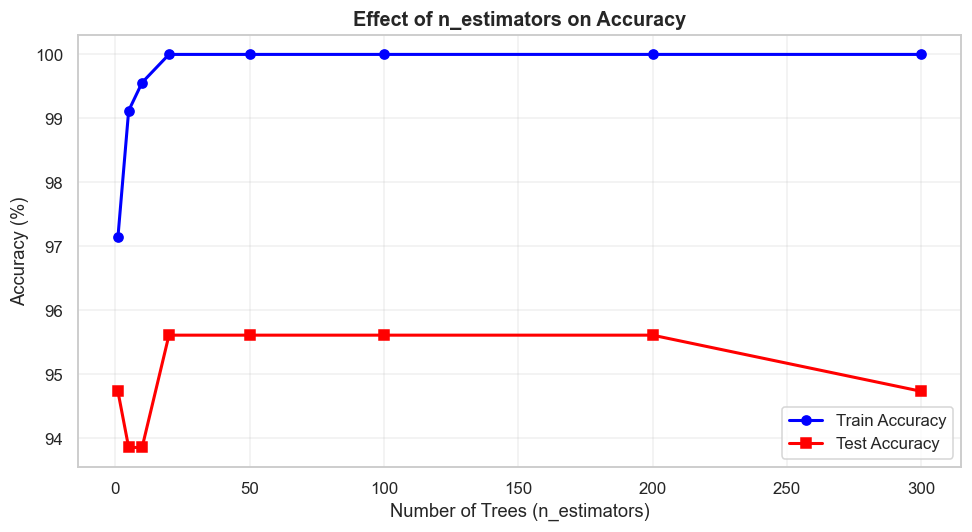

In [39]:
# ── Exercise 2 — SOLUTION ──
n_tree_values = [1, 5, 10, 20, 50, 100, 200, 300]
train_scores, test_scores = [], []

for n in n_tree_values:
    clf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(n_tree_values, [s*100 for s in train_scores], 'b-o', label='Train Accuracy', linewidth=2)
plt.plot(n_tree_values, [s*100 for s in test_scores],  'r-s', label='Test Accuracy',  linewidth=2)
plt.xlabel('Number of Trees (n_estimators)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Effect of n_estimators on Accuracy', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
### Exercise 3 — Max Depth Analysis
Train Random Forest classifiers with `max_depth` values `[1, 2, 3, 5, 8, 10, 15, None]`. Plot train and test accuracy side-by-side and identify the sweet spot.

In [40]:
# ── Exercise 3 — Your solution here ──


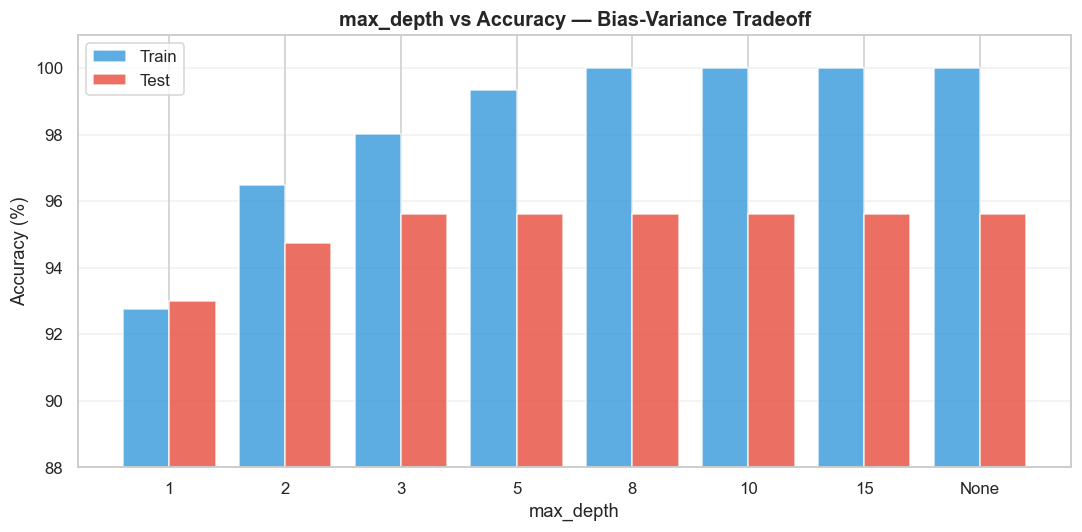

Best max_depth for test accuracy: 3


In [41]:
# ── Exercise 3 — SOLUTION ──
depth_values = [1, 2, 3, 5, 8, 10, 15, None]
labels       = [str(d) if d is not None else 'None' for d in depth_values]
train_d, test_d = [], []

for d in depth_values:
    clf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    train_d.append(accuracy_score(y_train, clf.predict(X_train)) * 100)
    test_d.append(accuracy_score(y_test, clf.predict(X_test)) * 100)

x = np.arange(len(labels))
plt.figure(figsize=(10, 5))
plt.bar(x - 0.2, train_d, 0.4, label='Train', color='#3498db', alpha=0.8)
plt.bar(x + 0.2, test_d,  0.4, label='Test',  color='#e74c3c', alpha=0.8)
plt.xticks(x, labels); plt.ylim(88, 101)
plt.xlabel('max_depth', fontsize=12); plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('max_depth vs Accuracy — Bias-Variance Tradeoff', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()
best_d = labels[np.argmax(test_d)]
print(f'Best max_depth for test accuracy: {best_d}')

---
### Exercise 4 — ROC Curve
Plot the **ROC curve** for the best-tuned Random Forest model. Compute and display the **AUC score**.

In [42]:
# ── Exercise 4 — Your solution here ──


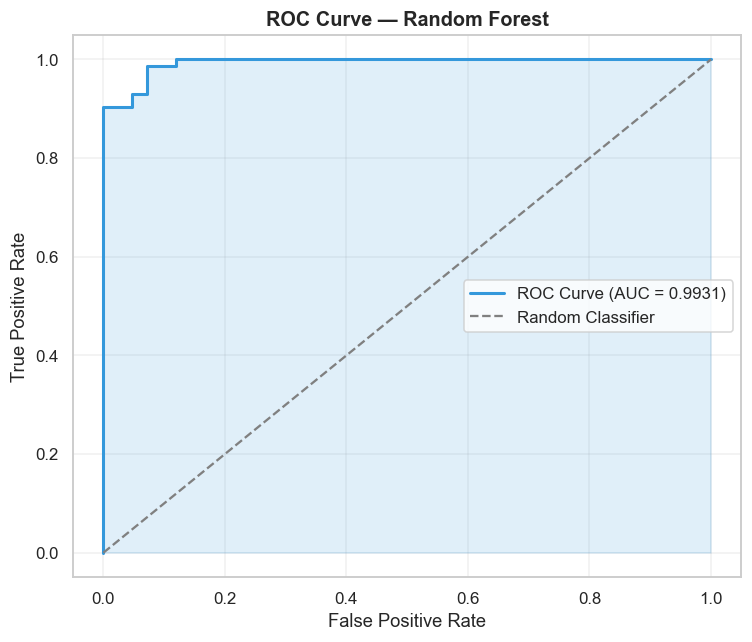

AUC Score: 0.9931


In [43]:
# ── Exercise 4 — SOLUTION ──
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#3498db', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.15, color='#3498db')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Random Forest', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f'AUC Score: {auc:.4f}')

---
### Exercise 5 — Compare with a Single Decision Tree
Train a single `DecisionTreeClassifier` and compare its accuracy and cross-validation score against the Random Forest. Explain why the ensemble performs better.

In [44]:
# ── Exercise 5 — Your solution here ──


In [45]:
# ── Exercise 5 — SOLUTION ──
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
dt_test_acc = accuracy_score(y_test, dt_clf.predict(X_test))
dt_cv_scores = cross_val_score(dt_clf, X_scaled, y, cv=5)
rf_cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42), X_scaled, y, cv=5
)

print('─' * 52)
print(f'{'Model':<22} {'Test Acc':>10} {'CV Mean':>10} {'CV Std':>8}')
print('─' * 52)
print(f'{'Decision Tree':<22} {dt_test_acc*100:>9.2f}% {dt_cv_scores.mean()*100:>9.2f}% {dt_cv_scores.std()*100:>7.2f}%')
print(f'{'Random Forest (100)':<22} {test_acc*100:>9.2f}% {rf_cv_scores.mean()*100:>9.2f}% {rf_cv_scores.std()*100:>7.2f}%')
print('─' * 52)
print()
print('Why Random Forest is better:')
print('  1. Reduces variance via averaging over many trees (bagging).')
print('  2. Random feature selection decorrelates individual trees.')
print('  3. Lower standard deviation → more reliable generalisation.')
print('  4. Less prone to overfitting compared to a single deep tree.')

────────────────────────────────────────────────────
Model                    Test Acc    CV Mean   CV Std
────────────────────────────────────────────────────
Decision Tree              91.23%     91.73%    2.42%
Random Forest (100)        95.61%     95.61%    2.28%
────────────────────────────────────────────────────

Why Random Forest is better:
  1. Reduces variance via averaging over many trees (bagging).
  2. Random feature selection decorrelates individual trees.
  3. Lower standard deviation → more reliable generalisation.
  4. Less prone to overfitting compared to a single deep tree.


---
## 🏁 Key Takeaways

| Concept | Key Point |
|---|---|
| **Ensemble power** | Many weak learners → one strong learner |
| **Bagging** | Bootstrap sampling reduces variance |
| **Random subspace** | Feature randomness decorrelates trees |
| **OOB score** | Free validation without a held-out set |
| **Feature importance** | MDI ranks each feature's predictive contribution |
| **Hyperparameters** | `n_estimators` and `max_depth` are most impactful |
| **Versatility** | Works for both classification and regression |
| **Robustness** | Handles missing data, outliers, and high-dimensional inputs well |

---
### 📚 Further Reading
- Breiman, L. (2001). *Random Forests*. Machine Learning, 45, 5–32.
- [scikit-learn RandomForestClassifier docs](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
- [scikit-learn Ensemble Methods guide](https://scikit-learn.org/stable/modules/ensemble.html)